In [ ]:
# Cell 1 - Config
import os, numpy as np, rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings; warnings.filterwarnings('ignore')

SILT_DIR = r'C:/Users/PRABHAKAR/Documents/Wells-Lab/outputs/08_silt'
OUT_DIR  = os.path.join(SILT_DIR, 'validation')
os.makedirs(OUT_DIR, exist_ok=True)
LOW, MEDIUM = 0.5, 1.0

PRED = {
    'ATTANUR_1': os.path.join(SILT_DIR, 'ATTANUR_1_silt.tif'),
    'ATTANUR_2': os.path.join(SILT_DIR, 'ATTANUR_2_silt.tif'),
    'ATTANUR_3': os.path.join(SILT_DIR, 'ATTANUR_3_silt.tif'),
    'ATTANUR_4': os.path.join(SILT_DIR, 'ATTANUR_4_silt.tif'),
}
ACTUAL = {
    'ATTANUR_1': os.path.join(SILT_DIR, 'actual_silt_depth_ATTANUR_1.tif'),
    'ATTANUR_2': os.path.join(SILT_DIR, 'actual_silt_depth_ATTANUR_2.tif'),
    'ATTANUR_3': os.path.join(SILT_DIR, 'actual_silt_depth_ATTANUR_3.tif'),
    'ATTANUR_4': os.path.join(SILT_DIR, 'actual_silt_depth_ATTANUR_4.tif'),
}

print('File check:')
for tag in PRED:
    p = 'OK' if os.path.exists(PRED[tag])   else 'MISSING'
    a = 'OK' if os.path.exists(ACTUAL[tag]) else 'MISSING'
    print(f'  {tag}  prediction={p}  actual_depth={a}')

# Ortho files for background visualisation
DATA_DIR = r'c:/Users/PRABHAKAR/Documents/Wells-Lab'
ORTHO = {
    'ATTANUR_1': r'c:/Users/PRABHAKAR/Documents/Wells-Lab/_keep_locally/TLBC_D95_ATTANUR_1_ortho.tif',
    'ATTANUR_2': r'c:/Users/PRABHAKAR/Documents/Wells-Lab/TLBC_D95_ATTANUR_2_ortho.tif',
    'ATTANUR_3': r'c:/Users/PRABHAKAR/Documents/Wells-Lab/_keep_locally/TLBC_D95_ATTANUR_3_ortho.tif',
    'ATTANUR_4': r'c:/Users/PRABHAKAR/Documents/Wells-Lab/_keep_locally/TLBC_D95_ATTANUR_4_ortho.tif',
}


In [ ]:
# Cell 2 - Validation function
def validate(tag):
    print('-'*50)
    print('Validating:', tag)
    if not os.path.exists(PRED[tag]):
        print('  prediction file missing'); return None
    if not os.path.exists(ACTUAL[tag]):
        print('  actual depth file missing'); return None

    try:
        with rasterio.open(PRED[tag]) as s:
            pred = s.read(1).astype(np.float32)
            h, w = pred.shape
    except Exception as e:
        print('  ERROR reading prediction:', e); return None

    try:
        with rasterio.open(ACTUAL[tag]) as s:
            depth  = s.read(1, out_shape=(h,w), resampling=Resampling.bilinear).astype(np.float32)
            nodata = s.nodata
    except Exception as e:
        print('  ERROR reading actual depth file (corrupted?):', e)
        print('  Re-export this tile from QGIS and replace the file.')
        return None

    dmin = float(np.nanmin(depth)); dmax = float(np.nanmax(depth))
    print(f'  Depth range : {dmin:.3f}m  to  {dmax:.3f}m')

    valid = np.isfinite(depth) & (pred > 0) & (depth > -5) & (depth < 20)
    if nodata is not None:
        valid &= (np.abs(depth - nodata) > 0.001)
    print(f'  Canal pixels: {valid.sum():,}')
    if valid.sum() < 10:
        print('  Too few valid pixels'); return None

    ac = np.zeros_like(depth, dtype=np.uint8)
    ac[valid & (depth >= 0)   & (depth < LOW)]    = 1
    ac[valid & (depth >= LOW) & (depth < MEDIUM)] = 2
    ac[valid & (depth >= MEDIUM)]                 = 3

    p, a = pred[valid].astype(np.uint8), ac[valid]
    acc  = 100.0 * (p == a).sum() / len(p)

    print(f'  Overall Accuracy : {acc:.1f}%')
    print('-'*65)
    print(f'  {"Class":<5} {"Name":<18} {"Actual":>8} {"Pred":>8} {"Correct":>8} {"Recall":>8} {"Precis":>8} {"F1":>6}')
    print('-'*65)
    for cls, name in [(1,'Low  (<0.5m)'),(2,'Medium (0.5-1m)'),(3,'High  (>1m)')]:
        an  = (a==cls).sum(); pn=(p==cls).sum(); cor=((a==cls)&(p==cls)).sum()
        rec = 100*cor/an if an>0 else 0
        pre = 100*cor/pn if pn>0 else 0
        f1  = 2*rec*pre/(rec+pre) if (rec+pre)>0 else 0
        print(f'  {cls:<5} {name:<18} {an:>8,} {pn:>8,} {cor:>8,} {rec:>7.1f}% {pre:>7.1f}% {f1:>5.1f}%')
    return acc, pred, ac, depth, valid

print('Validation function ready.')


In [ ]:
# Cell 3 - Run validation
results, data = {}, {}
for tag in PRED:
    out = validate(tag)
    if out:
        results[tag] = out[0]
        data[tag]    = out[1:]

if results:
    print('='*50)
    print('FINAL SUMMARY')
    print('='*50)
    for tag, acc in results.items():
        bar    = chr(9608) * int(acc // 5)
        status = 'GOOD' if acc >= 70 else 'NEEDS REVIEW'
        print(f'  {tag:<12}  {acc:5.1f}%  {bar:<22} {status}')
    avg = np.mean(list(results.values()))
    print(f'  Average accuracy: {avg:.1f}%')
else:
    print('No results - check paths in Cell 1')


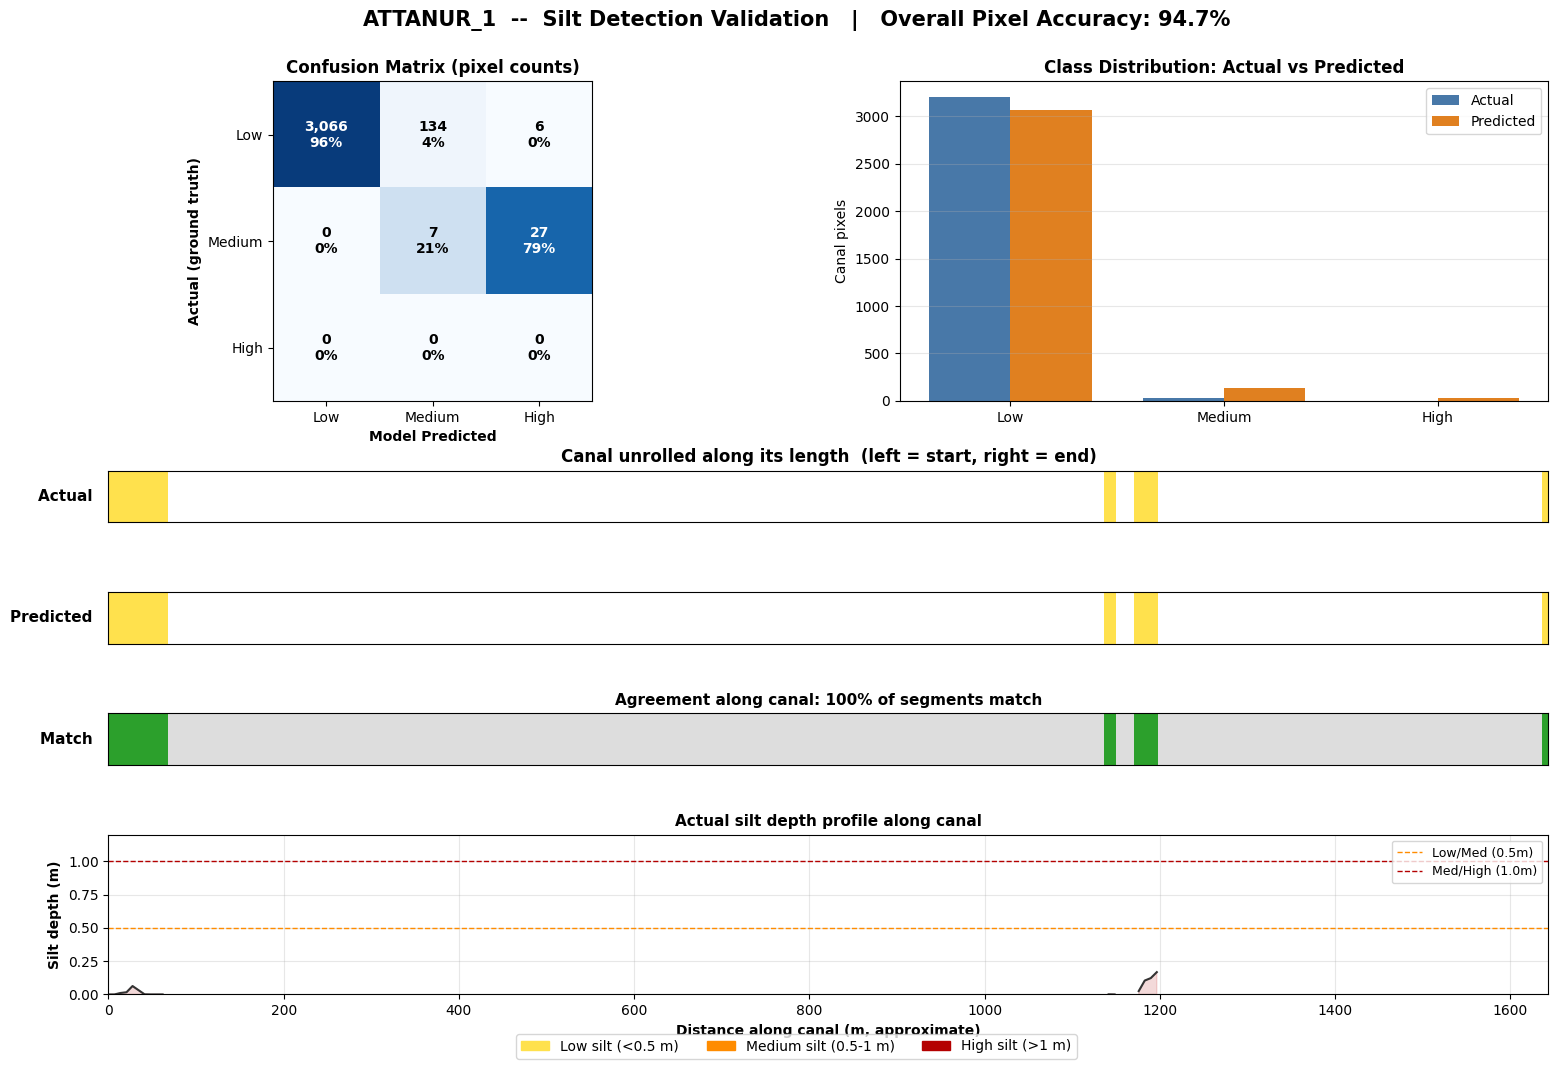

Saved: C:/Users/PRABHAKAR/Documents/Wells-Lab/outputs/08_silt\validation\ATTANUR_1_validation.png   (canal ~1644 m, segment agreement 100%)


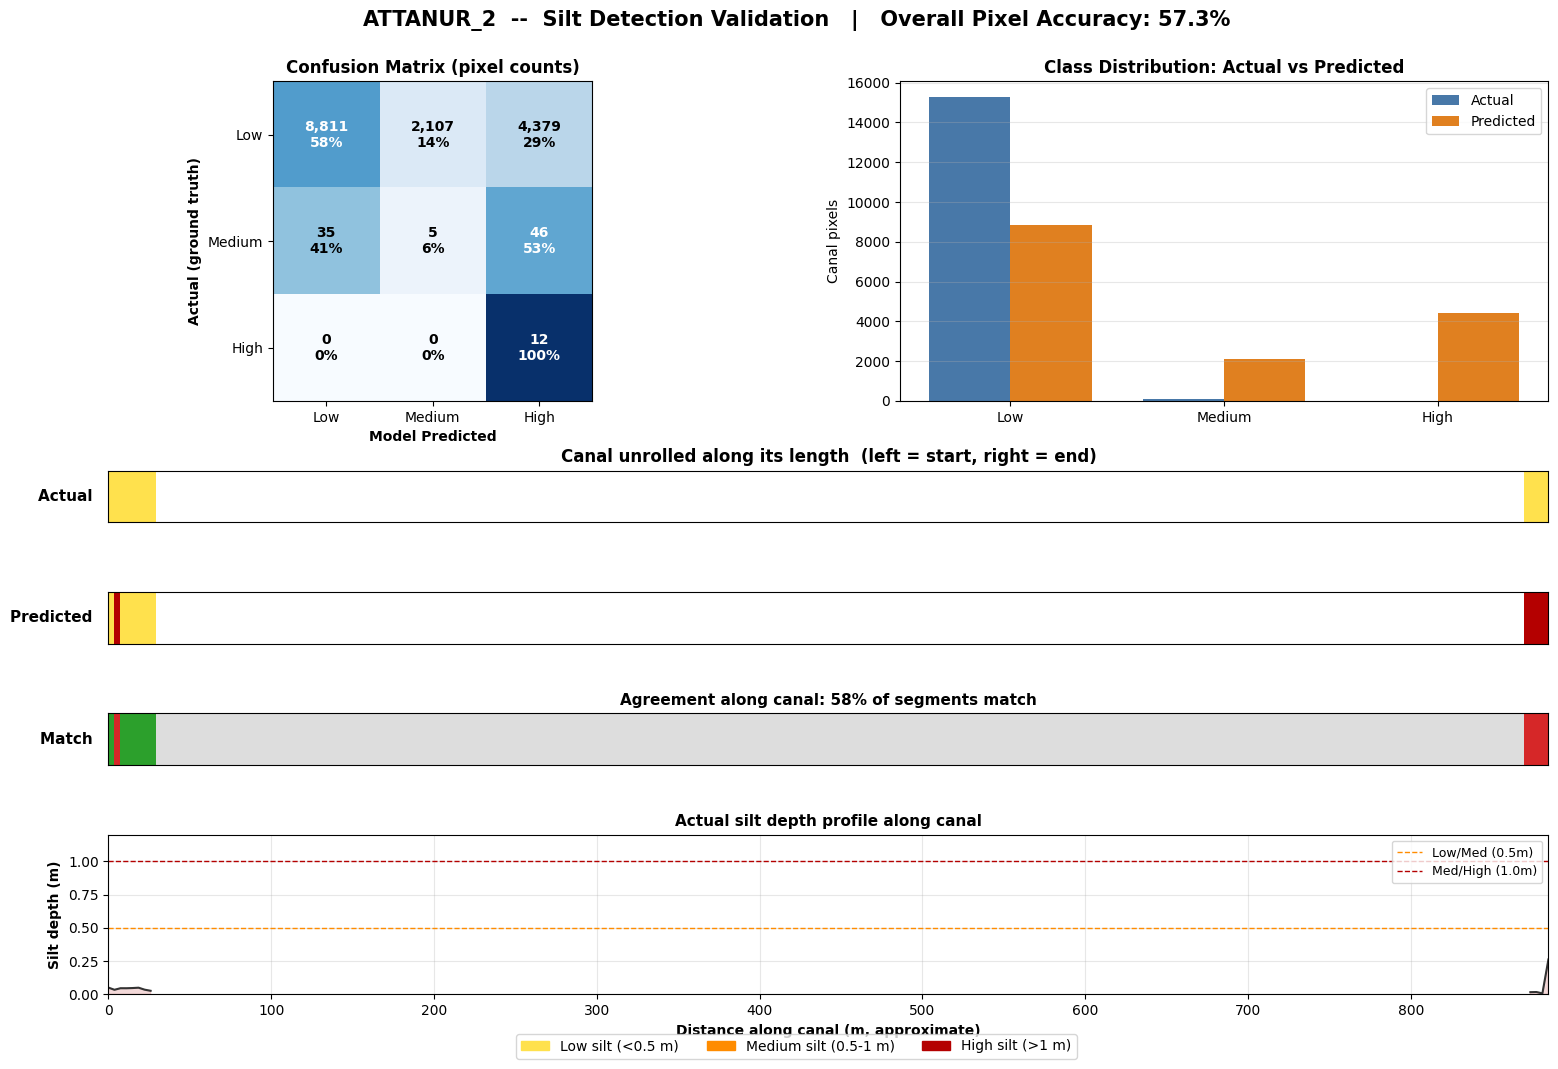

Saved: C:/Users/PRABHAKAR/Documents/Wells-Lab/outputs/08_silt\validation\ATTANUR_2_validation.png   (canal ~885 m, segment agreement 58%)


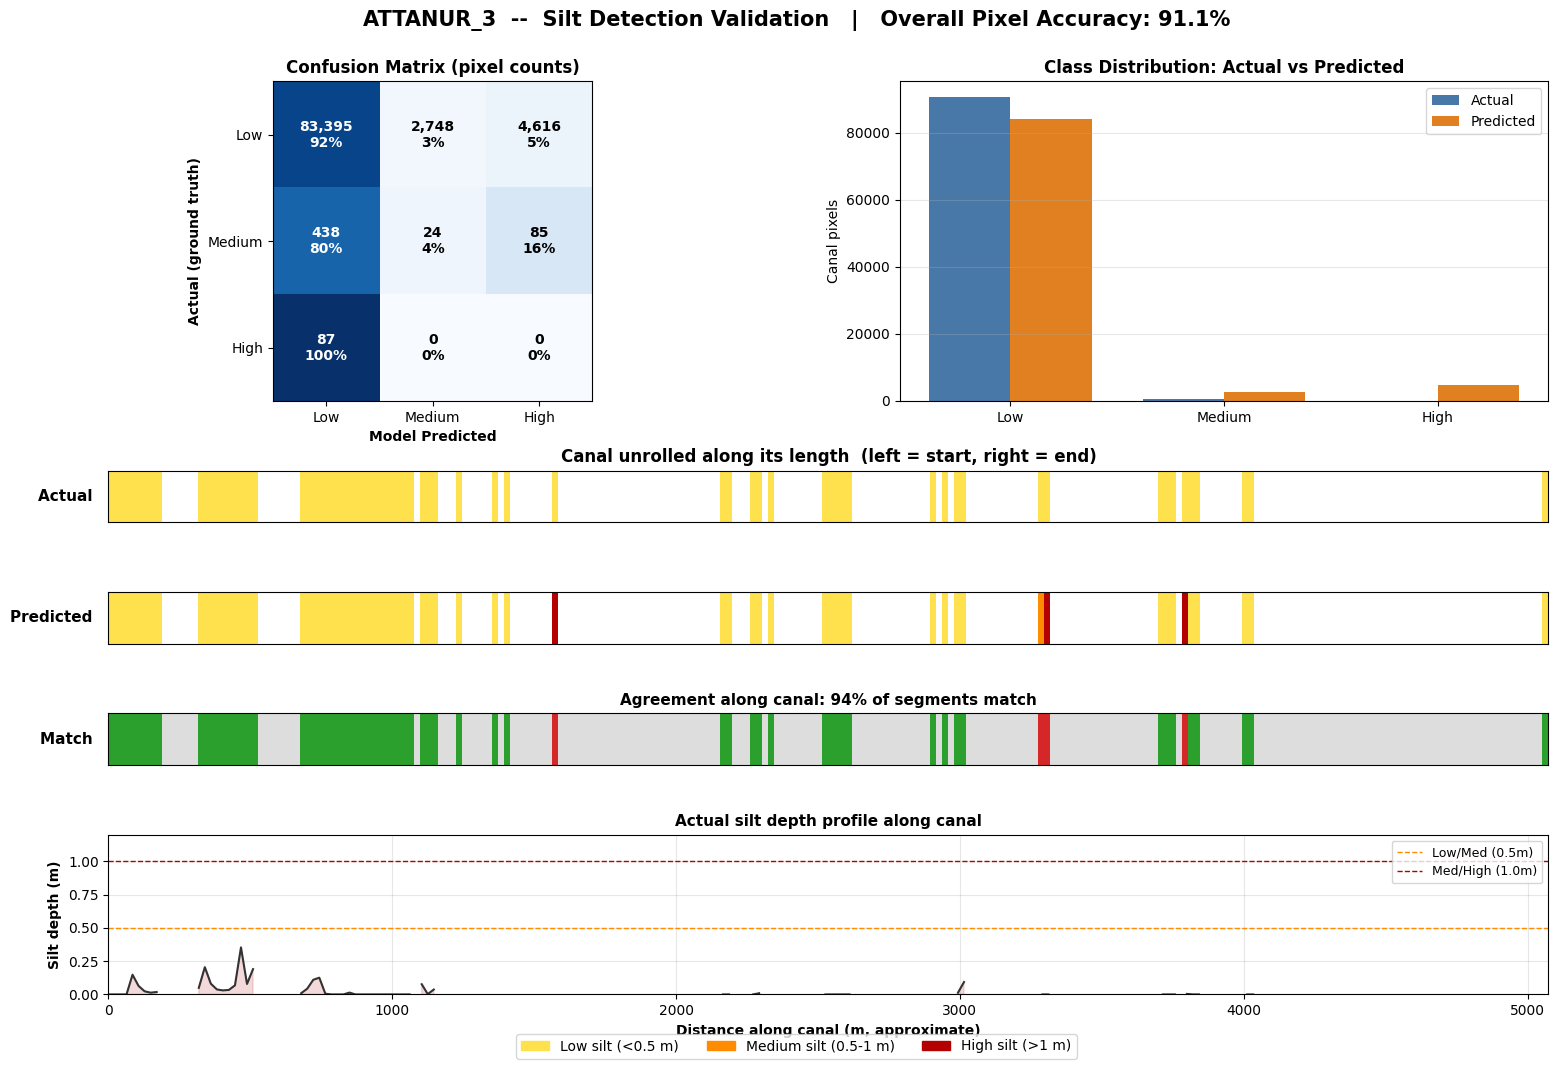

Saved: C:/Users/PRABHAKAR/Documents/Wells-Lab/outputs/08_silt\validation\ATTANUR_3_validation.png   (canal ~5074 m, segment agreement 94%)


In [29]:
# Cell 4 - Validation visualisation: canal 'unrolled' along its length
# Shows confusion matrix, class distribution, actual-vs-predicted ribbons,
# agreement strip, and the silt depth profile.  Self-contained.
import gc
from matplotlib.colors import ListedColormap, BoundaryNorm

# Fallbacks so this cell works even if run standalone
OUT_DIR = globals().get('OUT_DIR', os.path.join(SILT_DIR, 'validation'))
os.makedirs(OUT_DIR, exist_ok=True)
LOW    = globals().get('LOW', 0.5)
MEDIUM = globals().get('MEDIUM', 1.0)

CLASS_CMAP = ListedColormap(['#ffffff', '#ffe14d', '#ff8c00', '#b40000'])
CLASS_NORM = BoundaryNorm([-.5,.5,1.5,2.5,3.5], CLASS_CMAP.N)
LABELS = ['Low','Medium','High']
PX_M = 0.37   # approx ground size of one silt-map pixel (ortho ~0.046m x DS 8)

def unroll_canal(valid, pred, ac, depth, nbins=240):
    """Order canal pixels along their principal axis, bin into a 1-D ribbon."""
    ys, xs = np.where(valid)
    pts = np.column_stack([xs, ys]).astype(np.float64)
    c = pts - pts.mean(0)
    evals, evecs = np.linalg.eigh(np.cov(c.T))
    axis = evecs[:, np.argmax(evals)]      # principal direction = down-canal
    t = c @ axis
    tn = (t - t.min()) / (t.max() - t.min() + 1e-9)
    bins = np.clip((tn * nbins).astype(int), 0, nbins-1)
    pv = pred[ys, xs].astype(int); av = ac[ys, xs].astype(int); dv = depth[ys, xs]
    a_strip = np.zeros(nbins, int); p_strip = np.zeros(nbins, int)
    d_prof = np.full(nbins, np.nan); n_per = np.zeros(nbins, int)
    for b in range(nbins):
        m = bins == b; n_per[b] = m.sum()
        if m.sum() == 0: continue
        a_strip[b] = np.bincount(av[m], minlength=4).argmax()
        p_strip[b] = np.bincount(pv[m], minlength=4).argmax()
        d_prof[b]  = np.nanmean(dv[m])
    length_m = (t.max() - t.min()) * PX_M
    return a_strip, p_strip, d_prof, n_per, length_m

for tag, (pred, ac, depth, valid) in data.items():
    acc = results[tag]
    if valid.sum() < 10:
        print(tag, ': too few valid pixels, skipping'); continue
    a_strip, p_strip, d_prof, n_per, length_m = unroll_canal(valid, pred, ac, depth)
    nbins = len(a_strip)

    # confusion matrix (rows=actual 1..3, cols=pred 1..3)
    p = pred[valid].astype(int); a = ac[valid].astype(int)
    cm = np.zeros((3,3), int)
    for i in range(1,4):
        for j in range(1,4):
            cm[i-1, j-1] = int(((a==i) & (p==j)).sum())
    cm_norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)

    fig = plt.figure(figsize=(16, 11)); fig.patch.set_facecolor('white')
    gs = fig.add_gridspec(5, 2, height_ratios=[2.6,0.42,0.42,0.42,1.3],
                          hspace=0.55, wspace=0.22,
                          left=0.07, right=0.97, top=0.9, bottom=0.07)

    # confusion matrix
    ax_cm = fig.add_subplot(gs[0,0])
    ax_cm.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax_cm.set_xticks(range(3)); ax_cm.set_xticklabels(LABELS)
    ax_cm.set_yticks(range(3)); ax_cm.set_yticklabels(LABELS)
    ax_cm.set_xlabel('Model Predicted', fontweight='bold')
    ax_cm.set_ylabel('Actual (ground truth)', fontweight='bold')
    ax_cm.set_title('Confusion Matrix (pixel counts)', fontweight='bold')
    for i in range(3):
        for j in range(3):
            ax_cm.text(j, i, f'{cm[i,j]:,}\n{100*cm_norm[i,j]:.0f}%', ha='center',
                       va='center', fontsize=10, fontweight='bold',
                       color='white' if cm_norm[i,j]>0.5 else 'black')

    # class distribution
    ax_bar = fig.add_subplot(gs[0,1])
    act_c = [int((a==k).sum()) for k in (1,2,3)]
    prd_c = [int((p==k).sum()) for k in (1,2,3)]
    x = np.arange(3); wb = 0.38
    ax_bar.bar(x-wb/2, act_c, wb, label='Actual',    color='#4878a8')
    ax_bar.bar(x+wb/2, prd_c, wb, label='Predicted', color='#e08020')
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(LABELS)
    ax_bar.set_ylabel('Canal pixels')
    ax_bar.set_title('Class Distribution: Actual vs Predicted', fontweight='bold')
    ax_bar.legend(); ax_bar.grid(axis='y', alpha=0.3)

    # ribbons
    def ribbon(ax, strip, lbl):
        ax.imshow(strip.reshape(1,-1), cmap=CLASS_CMAP, norm=CLASS_NORM, aspect='auto')
        ax.set_yticks([]); ax.set_xticks([])
        ax.set_ylabel(lbl, rotation=0, ha='right', va='center', fontweight='bold', fontsize=11)
    ax_a = fig.add_subplot(gs[1,:]); ribbon(ax_a, a_strip, 'Actual  ')
    ax_a.set_title('Canal unrolled along its length  (left = start, right = end)',
                   fontweight='bold', fontsize=12)
    ax_p = fig.add_subplot(gs[2,:]); ribbon(ax_p, p_strip, 'Predicted  ')

    match = np.where(n_per==0, 0, np.where(a_strip==p_strip, 1, 2))
    MATCH_CMAP = ListedColormap(['#dddddd', '#2ca02c', '#d62728'])
    ax_m = fig.add_subplot(gs[3,:])
    ax_m.imshow(match.reshape(1,-1), cmap=MATCH_CMAP, vmin=0, vmax=2, aspect='auto')
    ax_m.set_yticks([]); ax_m.set_xticks([])
    ax_m.set_ylabel('Match  ', rotation=0, ha='right', va='center', fontweight='bold', fontsize=11)
    seg_acc = 100*(match==1).sum()/max(1,(match>0).sum())
    ax_m.set_title(f'Agreement along canal: {seg_acc:.0f}% of segments match',
                   fontweight='bold', fontsize=11)

    # depth profile
    ax_d = fig.add_subplot(gs[4,:])
    xm = np.linspace(0, length_m, nbins)
    ax_d.plot(xm, d_prof, color='#333', lw=1.5)
    ax_d.fill_between(xm, 0, d_prof, where=~np.isnan(d_prof), color='#b40000', alpha=0.15)
    ax_d.axhline(LOW,    color='#ff8c00', ls='--', lw=1, label=f'Low/Med ({LOW}m)')
    ax_d.axhline(MEDIUM, color='#b40000', ls='--', lw=1, label=f'Med/High ({MEDIUM}m)')
    ax_d.set_xlim(0, length_m)
    ymax = np.nanmax(d_prof) if np.isfinite(np.nanmax(d_prof)) else 1.2
    ax_d.set_ylim(0, max(ymax*1.1, 1.2))
    ax_d.set_xlabel('Distance along canal (m, approximate)', fontweight='bold')
    ax_d.set_ylabel('Silt depth (m)', fontweight='bold')
    ax_d.set_title('Actual silt depth profile along canal', fontweight='bold', fontsize=11)
    ax_d.legend(loc='upper right', fontsize=9); ax_d.grid(alpha=0.3)

    patches = [mpatches.Patch(color='#ffe14d', label='Low silt (<0.5 m)'),
               mpatches.Patch(color='#ff8c00', label='Medium silt (0.5-1 m)'),
               mpatches.Patch(color='#b40000', label='High silt (>1 m)')]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 0.005))
    fig.suptitle(f'{tag}  --  Silt Detection Validation   |   Overall Pixel Accuracy: {acc:.1f}%',
                 fontsize=15, fontweight='bold', y=0.965)

    save = os.path.join(OUT_DIR, tag + '_validation.png')
    plt.savefig(save, dpi=110, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save}   (canal ~{length_m:.0f} m, segment agreement {seg_acc:.0f}%)')
    plt.close(fig); gc.collect()


In [30]:
# Cell 5 - Spot check high-silt pixels
for tag, (pred, ac, depth, valid) in data.items():
    hi = np.where(valid & (ac == 3))
    if len(hi[0]) == 0:
        print(tag, ': no high silt pixels'); continue
    print(tag, '- High Silt spot check:')
    print(f'  {"Row":>6} {"Col":>6} {"Depth":>10} {"Pred":>6} {"Match":>6}')
    idx = np.random.choice(len(hi[0]), size=min(5, len(hi[0])), replace=False)
    for i in idx:
        r, c  = hi[0][i], hi[1][i]
        d, pp = float(depth[r,c]), int(pred[r,c])
        match = 'YES' if pp == 3 else 'NO'
        print(f'  {r:>6} {c:>6} {d:>9.3f}m {pp:>6} {match:>6}')


ATTANUR_1 : no high silt pixels
ATTANUR_2 - High Silt spot check:
     Row    Col      Depth   Pred  Match
    2392   3884     1.137m      3    YES
    2394   3883     1.024m      3    YES
    2392   3885     1.255m      3    YES
    2398   3882     1.029m      3    YES
    2393   3884     1.137m      3    YES
ATTANUR_3 - High Silt spot check:
     Row    Col      Depth   Pred  Match
    1710   5367     1.126m      1     NO
    1706   5372     1.051m      1     NO
    1703   5367     1.379m      1     NO
    1711   5368     1.090m      1     NO
    1707   5368     1.315m      1     NO
